# Cancer Type Classification from Gene Expression Data Using Autoencoder-Based Dimensionality Reduction

**Course:** MSE 5760-001 Machine Learning And Its Applications In Materials Science

**Dataset:** TCGA Pan-Cancer Atlas RNA-Seq Gene Expression (UCSC Xena)

**Objective:** Use Stacked Denoising Autoencoder (SDAE), Variational Autoencoder (VAE), and PCA for dimensionality reduction, then classify cancer types.

---

## 1. Environment Setup

In [ ]:
!pip install -q umap-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
!rm -f /content/expression.tsv.gz /content/expression.tsv


!curl -L -o /content/expression.tsv.gz "https://pancanatlas.xenahubs.net/download/EB%2B%2BAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena.gz"

!ls -lh /content/expression.tsv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   110  100   110    0     0    109      0  0:00:01  0:00:01 --:--:--   109
100  315M  100  315M    0     0  14.6M      0  0:00:21  0:00:21 --:--:-- 16.9M
-rw-r--r-- 1 root root 316M Apr 15 04:26 /content/expression.tsv.gz


In [ ]:

!ls -lh /content/expression*


!gunzip -f /content/expression.tsv.gz


import gzip
import shutil
try:
    with gzip.open('/content/expression.tsv.gz', 'rb') as f_in:
        with open('/content/expression.tsv', 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("Python解压成功！")
except Exception as e:
    print(f"Error: {e}")

!ls -lh /content/expression.tsv

-rw-r--r-- 1 root root 316M Apr 15 04:26 /content/expression.tsv.gz
Error: [Errno 2] No such file or directory: '/content/expression.tsv.gz'
-rw-r--r-- 1 root root 1.1G Apr 15 04:26 /content/expression.tsv


## 2. Download TCGA Pan-Cancer Data from UCSC Xena

Data is downloaded directly — no API key or account needed.

## 3. Data Loading & Exploration

In [ ]:
# Load expression data (genes as rows, samples as columns -> transpose)
print("Loading expression data... (this may take ~1 min)")
df_expr = pd.read_csv('/content/expression.tsv', sep='\t', index_col=0).T

# Load phenotype labels
df_labels = pd.read_csv('/content/phenotype.tsv', sep='\t', index_col=0)

print(f"Expression data (raw): {df_expr.shape}")
print(f"Phenotype data (raw): {df_labels.shape}")
print(f"\nPhenotype columns: {df_labels.columns.tolist()}")

Loading expression data... (this may take ~1 min)
Expression data (raw): (11069, 20531)
Phenotype data (raw): (12804, 3)

Phenotype columns: ['sample_type_id', 'sample_type', '_primary_disease']


In [ ]:
# Align samples between expression and labels
common = df_expr.index.intersection(df_labels.index)
df_expr = df_expr.loc[common]
df_labels = df_labels.loc[common]

# Use cancer type column
label_col = '_primary_disease'

# Drop samples with missing labels
mask = df_labels[label_col].notna()
df_expr = df_expr[mask]
df_labels = df_labels[mask]

print(f"Aligned expression data: {df_expr.shape}")
print(f"Aligned labels: {df_labels.shape}")
print(f"\nNumber of cancer types: {df_labels[label_col].nunique()}")
print(f"\nCancer type distribution:")
print(df_labels[label_col].value_counts())

Aligned expression data: (11060, 20531)
Aligned labels: (11060, 3)

Number of cancer types: 33

Cancer type distribution:
_primary_disease
breast invasive carcinoma                1218
kidney clear cell carcinoma               606
lung adenocarcinoma                       576
thyroid carcinoma                         572
uterine corpus endometrioid carcinoma     567
head & neck squamous cell carcinoma       566
lung squamous cell carcinoma              553
prostate adenocarcinoma                   550
brain lower grade glioma                  530
colon adenocarcinoma                      495
skin cutaneous melanoma                   474
stomach adenocarcinoma                    450
bladder urothelial carcinoma              427
liver hepatocellular carcinoma            423
kidney papillary cell carcinoma           323
cervical & endocervical cancer            310
ovarian serous cystadenocarcinoma         308
sarcoma                                   265
esophageal carcinoma             

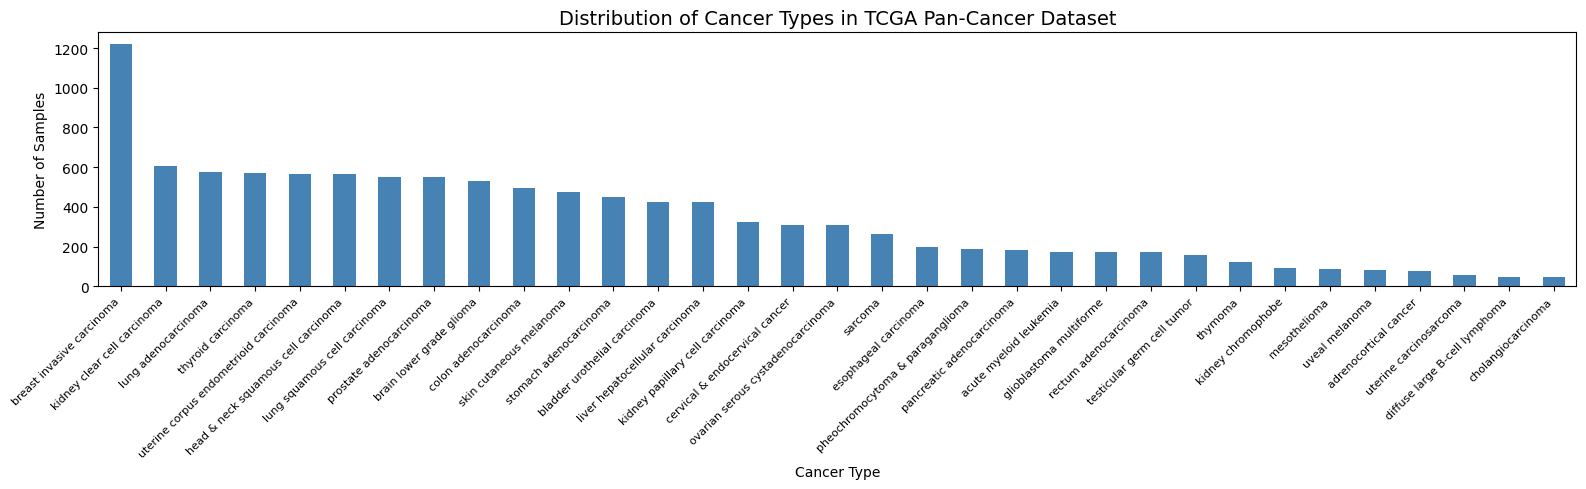

In [ ]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(16, 5))
df_labels[label_col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribution of Cancer Types in TCGA Pan-Cancer Dataset', fontsize=14)
ax.set_xlabel('Cancer Type')
ax.set_ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

1. Handle missing values
2. Select top 5,000 most variable genes
3. Z-score normalization
4. Encode labels
5. Stratified 80/20 train-test split

In [ ]:
# Prepare data matrix
X = df_expr.values.astype(np.float32)
y_raw = df_labels[label_col].values

# Handle missing values
print(f"Missing values: {np.isnan(X).sum()}")
X = np.nan_to_num(X, nan=0.0)

print(f"Data matrix: {X.shape[0]} samples x {X.shape[1]} genes")

Missing values: 3971737
Data matrix: 11060 samples x 20531 genes


In [ ]:
# Select top 5000 most variable genes
N_TOP_GENES = 5000
gene_var = np.var(X, axis=0)
top_idx = np.argsort(gene_var)[-N_TOP_GENES:]
X_filtered = X[:, top_idx]

print(f"Original genes: {X.shape[1]}")
print(f"After filtering: {X_filtered.shape[1]}")

Original genes: 20531
After filtering: 5000


In [ ]:
# Z-score normalization
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_filtered)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
n_classes = len(le.classes_)
print(f"Number of classes: {n_classes}")
print(f"Classes: {le.classes_}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Number of classes: 33
Classes: ['acute myeloid leukemia' 'adrenocortical cancer'
 'bladder urothelial carcinoma' 'brain lower grade glioma'
 'breast invasive carcinoma' 'cervical & endocervical cancer'
 'cholangiocarcinoma' 'colon adenocarcinoma'
 'diffuse large B-cell lymphoma' 'esophageal carcinoma'
 'glioblastoma multiforme' 'head & neck squamous cell carcinoma'
 'kidney chromophobe' 'kidney clear cell carcinoma'
 'kidney papillary cell carcinoma' 'liver hepatocellular carcinoma'
 'lung adenocarcinoma' 'lung squamous cell carcinoma' 'mesothelioma'
 'ovarian serous cystadenocarcinoma' 'pancreatic adenocarcinoma'
 'pheochromocytoma & paraganglioma' 'prostate adenocarcinoma'
 'rectum adenocarcinoma' 'sarcoma' 'skin cutaneous melanoma'
 'stomach adenocarcinoma' 'testicular germ cell tumor' 'thymoma'
 'thyroid carcinoma' 'uterine carcinosarcoma'
 'uterine corpus endometrioid carcinoma' 'uveal melanoma']

Train: (8848, 5000), Test: (2212, 5000)


In [ ]:
# PyTorch tensors & DataLoaders
X_train_t = torch.FloatTensor(X_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

BS = 128
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BS, shuffle=True)
ae_loader = DataLoader(TensorDataset(X_train_t), batch_size=BS, shuffle=True)

INPUT_DIM = X_train.shape[1]
LATENT_DIM = 256
print(f"Input dim: {INPUT_DIM}, Latent dim: {LATENT_DIM}, Batch size: {BS}")

Input dim: 5000, Latent dim: 256, Batch size: 128


## 5. Model 1: Stacked Denoising Autoencoder (SDAE)

In [ ]:
class SDAE(nn.Module):
    def __init__(self, input_dim, latent_dim=256, noise=0.3):
        super().__init__()
        self.noise = noise
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2000), nn.BatchNorm1d(2000), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(2000, 500), nn.BatchNorm1d(500), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(500, latent_dim), nn.BatchNorm1d(latent_dim), nn.ReLU())
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 500), nn.BatchNorm1d(500), nn.ReLU(),
            nn.Linear(500, 2000), nn.BatchNorm1d(2000), nn.ReLU(),
            nn.Linear(2000, input_dim))

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        z = self.encoder(x + torch.randn_like(x) * self.noise)
        return self.decoder(z), z

sdae = SDAE(INPUT_DIM, LATENT_DIM).to(device)
print(sdae)
print(f"\nParameters: {sum(p.numel() for p in sdae.parameters()):,}")

SDAE(
  (encoder): Sequential(
    (0): Linear(in_features=5000, out_features=2000, bias=True)
    (1): BatchNorm1d(2000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=2000, out_features=500, bias=True)
    (5): BatchNorm1d(500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=500, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=256, out_features=500, bias=True)
    (1): BatchNorm1d(500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=500, out_features=2000, bias=True)
    (4): BatchNorm1d(2000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear

In [ ]:
def train_ae(model, loader, epochs=100, lr=1e-3, name="AE"):
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit = nn.MSELoss()
    hist = []
    for ep in range(epochs):
        model.train()
        loss_sum = 0
        for (x,) in loader:
            opt.zero_grad()
            xr, _ = model(x)
            loss = crit(xr, x)
            loss.backward()
            opt.step()
            loss_sum += loss.item()
        avg = loss_sum / len(loader)
        hist.append(avg)
        sched.step(avg)
        if (ep+1) % 10 == 0:
            print(f"  [{name}] Epoch {ep+1}/{epochs} | Loss: {avg:.6f}")
    return hist

print("Training SDAE...")
sdae_hist = train_ae(sdae, ae_loader, epochs=100, name="SDAE")

Training SDAE...
  [SDAE] Epoch 10/100 | Loss: 0.297994
  [SDAE] Epoch 20/100 | Loss: 0.267367
  [SDAE] Epoch 30/100 | Loss: 0.253387
  [SDAE] Epoch 40/100 | Loss: 0.242260
  [SDAE] Epoch 50/100 | Loss: 0.235399
  [SDAE] Epoch 60/100 | Loss: 0.233777
  [SDAE] Epoch 70/100 | Loss: 0.230217
  [SDAE] Epoch 80/100 | Loss: 0.229723
  [SDAE] Epoch 90/100 | Loss: 0.226912
  [SDAE] Epoch 100/100 | Loss: 0.207562


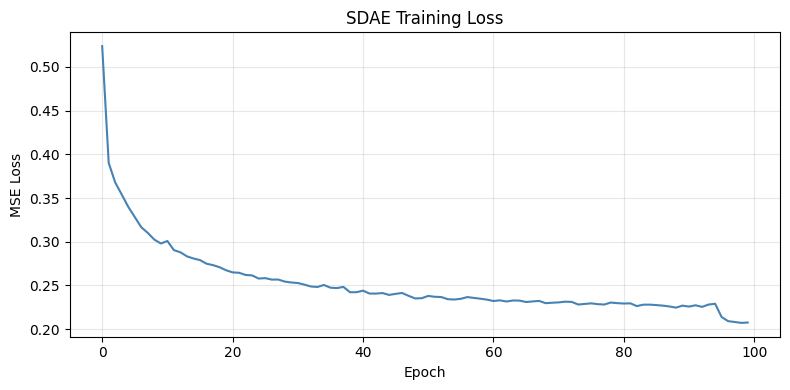

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(sdae_hist, color='steelblue')
plt.title('SDAE Training Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 6. Model 2: Variational Autoencoder (VAE)

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=256):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, 2000), nn.BatchNorm1d(2000), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(2000, 500), nn.BatchNorm1d(500), nn.ReLU())
        self.fc_mu = nn.Linear(500, latent_dim)
        self.fc_lv = nn.Linear(500, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 500), nn.BatchNorm1d(500), nn.ReLU(),
            nn.Linear(500, 2000), nn.BatchNorm1d(2000), nn.ReLU(),
            nn.Linear(2000, input_dim))

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_lv(h)

    def get_latent(self, x):
        mu, _ = self.encode(x)
        return mu

    def forward(self, x):
        mu, lv = self.encode(x)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.dec(z), mu, lv

vae = VAE(INPUT_DIM, LATENT_DIM).to(device)
print(vae)
print(f"\nParameters: {sum(p.numel() for p in vae.parameters()):,}")

VAE(
  (enc): Sequential(
    (0): Linear(in_features=5000, out_features=2000, bias=True)
    (1): BatchNorm1d(2000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=2000, out_features=500, bias=True)
    (5): BatchNorm1d(500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
  )
  (fc_mu): Linear(in_features=500, out_features=256, bias=True)
  (fc_lv): Linear(in_features=500, out_features=256, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=256, out_features=500, bias=True)
    (1): BatchNorm1d(500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=500, out_features=2000, bias=True)
    (4): BatchNorm1d(2000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=2000, out_features=5000, bias=True)
  )
)

Parameters: 22,404,512


In [ ]:
def train_vae(model, loader, epochs=100, lr=1e-3, beta=0.5):
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    hist = {'total': [], 'recon': [], 'kl': []}
    for ep in range(epochs):
        model.train()
        t, r, k = 0, 0, 0
        for (x,) in loader:
            opt.zero_grad()
            xr, mu, lv = model(x)
            recon = nn.MSELoss(reduction='sum')(xr, x)
            kl = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())
            loss = recon + beta * kl
            loss.backward()
            opt.step()
            t += loss.item(); r += recon.item(); k += kl.item()
        n = len(loader.dataset)
        hist['total'].append(t/n); hist['recon'].append(r/n); hist['kl'].append(k/n)
        sched.step(t/n)
        if (ep+1) % 10 == 0:
            print(f"  [VAE] Epoch {ep+1}/{epochs} | Total: {t/n:.4f} | Recon: {r/n:.4f} | KL: {k/n:.4f}")
    return hist

print("Training VAE...")
vae_hist = train_vae(vae, ae_loader, epochs=100)

Training VAE...
  [VAE] Epoch 10/100 | Total: 1569.1911 | Recon: 1484.2584 | KL: 169.8653
  [VAE] Epoch 20/100 | Total: 1371.9618 | Recon: 1295.0856 | KL: 153.7525
  [VAE] Epoch 30/100 | Total: 1251.2659 | Recon: 1181.4997 | KL: 139.5326
  [VAE] Epoch 40/100 | Total: 1163.5116 | Recon: 1097.3051 | KL: 132.4131
  [VAE] Epoch 50/100 | Total: 1099.9072 | Recon: 1035.3963 | KL: 129.0218
  [VAE] Epoch 60/100 | Total: 1055.1907 | Recon: 991.8084 | KL: 126.7647
  [VAE] Epoch 70/100 | Total: 1016.2514 | Recon: 953.9832 | KL: 124.5364
  [VAE] Epoch 80/100 | Total: 990.9651 | Recon: 929.2140 | KL: 123.5021
  [VAE] Epoch 90/100 | Total: 965.5307 | Recon: 904.2890 | KL: 122.4835
  [VAE] Epoch 100/100 | Total: 946.7104 | Recon: 885.7837 | KL: 121.8534


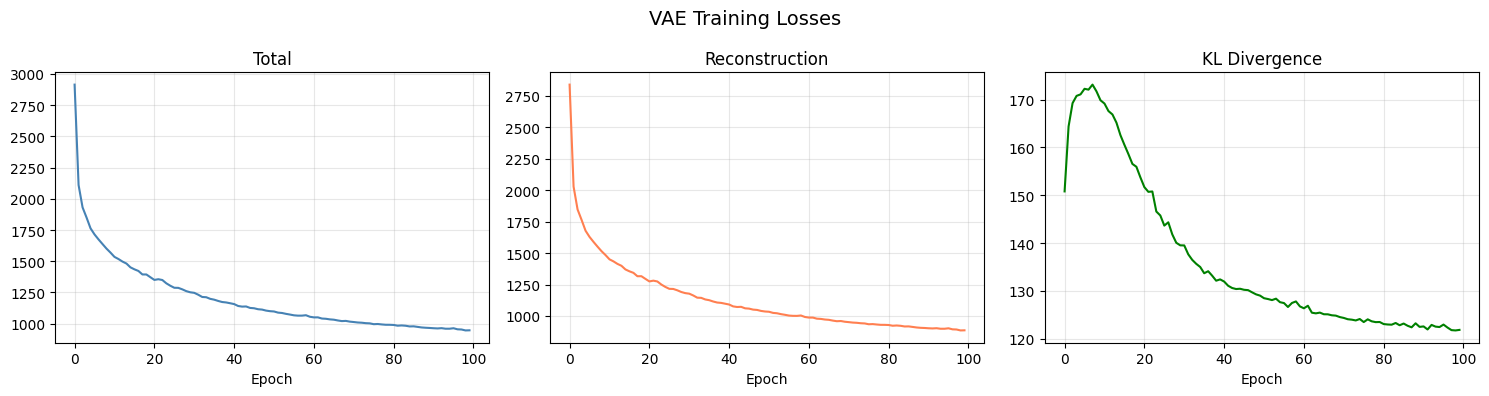

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (k, c, t) in zip(axes, [('total','steelblue','Total'), ('recon','coral','Reconstruction'), ('kl','green','KL Divergence')]):
    ax.plot(vae_hist[k], color=c); ax.set_title(t); ax.set_xlabel('Epoch'); ax.grid(True, alpha=0.3)
plt.suptitle('VAE Training Losses', fontsize=14); plt.tight_layout(); plt.show()

## 7. Feature Extraction & Latent Space Visualization

In [ ]:
import umap

sdae.eval(); vae.eval()
with torch.no_grad():
    Z_tr_s = sdae.encode(X_train_t).cpu().numpy()
    Z_te_s = sdae.encode(X_test_t).cpu().numpy()
    Z_tr_v = vae.get_latent(X_train_t).cpu().numpy()
    Z_te_v = vae.get_latent(X_test_t).cpu().numpy()

pca = PCA(n_components=LATENT_DIM, random_state=42)
Z_tr_p = pca.fit_transform(X_train)
Z_te_p = pca.transform(X_test)

print(f"SDAE: train={Z_tr_s.shape}, test={Z_te_s.shape}")
print(f"VAE:  train={Z_tr_v.shape}, test={Z_te_v.shape}")
print(f"PCA:  train={Z_tr_p.shape}, test={Z_te_p.shape}")
print(f"PCA explained variance: {pca.explained_variance_ratio_.cumsum()[-1]:.4f}")

SDAE: train=(8848, 256), test=(2212, 256)
VAE:  train=(8848, 256), test=(2212, 256)
PCA:  train=(8848, 256), test=(2212, 256)
PCA explained variance: 0.8206


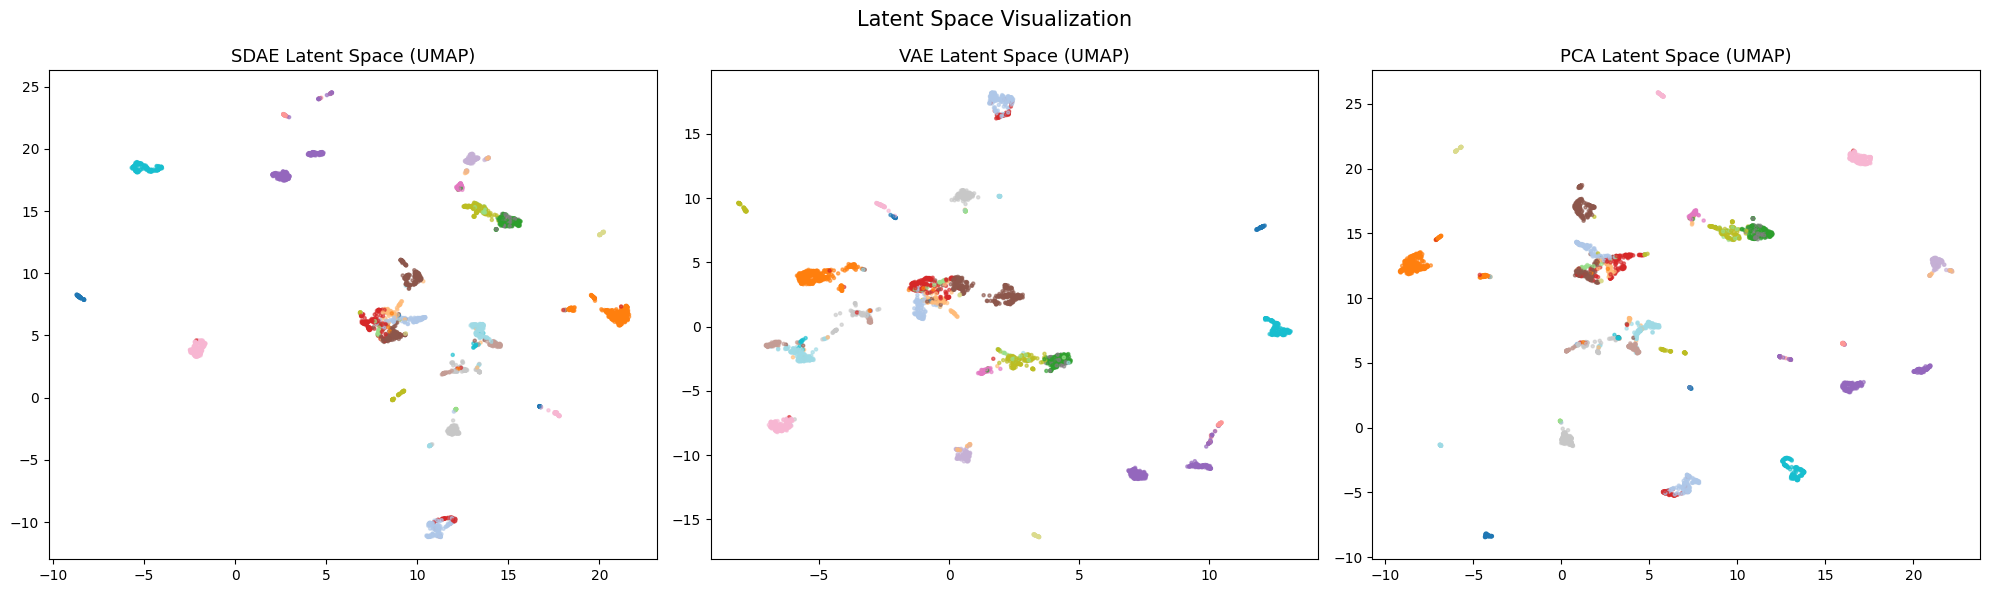

In [ ]:
# UMAP visualization
N = min(3000, len(Z_tr_s))
idx = np.random.choice(len(Z_tr_s), N, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, Z) in zip(axes, [('SDAE', Z_tr_s[idx]), ('VAE', Z_tr_v[idx]), ('PCA', Z_tr_p[idx])]):
    Z2 = umap.UMAP(random_state=42).fit_transform(Z)
    ax.scatter(Z2[:,0], Z2[:,1], c=y_train[idx], cmap='tab20', s=5, alpha=0.6)
    ax.set_title(f'{name} Latent Space (UMAP)', fontsize=13)
plt.suptitle('Latent Space Visualization', fontsize=15); plt.tight_layout(); plt.show()

## 8. Classification on Latent Features

In [ ]:
class Clf(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, d_out))
    def forward(self, x):
        return self.net(x)

def train_clf(model, Ztr, ytr, Zte, yte, epochs=100, lr=1e-3, name=""):
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit = nn.CrossEntropyLoss()
    Ztr_t = torch.FloatTensor(Ztr).to(device)
    ytr_t = torch.LongTensor(ytr).to(device)
    Zte_t = torch.FloatTensor(Zte).to(device)
    yte_t = torch.LongTensor(yte).to(device)
    ds = DataLoader(TensorDataset(Ztr_t, ytr_t), batch_size=128, shuffle=True)
    hist = {'loss':[], 'train_acc':[], 'test_acc':[]}

    for ep in range(epochs):
        model.train()
        tl, cor, tot = 0, 0, 0
        for xb, yb in ds:
            opt.zero_grad()
            out = model(xb)
            loss = crit(out, yb)
            loss.backward(); opt.step()
            tl += loss.item()
            cor += (out.argmax(1)==yb).sum().item()
            tot += len(yb)
        hist['loss'].append(tl/len(ds))
        hist['train_acc'].append(cor/tot)
        model.eval()
        with torch.no_grad():
            ta = (model(Zte_t).argmax(1)==yte_t).float().mean().item()
        hist['test_acc'].append(ta)
        sched.step(tl)
        if (ep+1) % 20 == 0:
            print(f"  [{name}] Ep {ep+1}/{epochs} | Loss: {hist['loss'][-1]:.4f} | Train: {cor/tot:.4f} | Test: {ta:.4f}")
    return hist

print("Classifier architecture:")
print(Clf(LATENT_DIM, n_classes))

Classifier architecture:
Clf(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=33, bias=True)
  )
)


In [ ]:
res = {}
for name, Ztr, Zte in [('SDAE', Z_tr_s, Z_te_s), ('VAE', Z_tr_v, Z_te_v), ('PCA', Z_tr_p, Z_te_p)]:
    print("="*60)
    print(f"Training {name} Classifier")
    print("="*60)
    clf = Clf(LATENT_DIM, n_classes).to(device)
    res[name] = (clf, train_clf(clf, Ztr, y_train, Zte, y_test, name=name))
    print()

Training SDAE Classifier
  [SDAE] Ep 20/100 | Loss: 0.1414 | Train: 0.9521 | Test: 0.9299
  [SDAE] Ep 40/100 | Loss: 0.1126 | Train: 0.9594 | Test: 0.9277
  [SDAE] Ep 60/100 | Loss: 0.0727 | Train: 0.9746 | Test: 0.9277
  [SDAE] Ep 80/100 | Loss: 0.0612 | Train: 0.9793 | Test: 0.9268
  [SDAE] Ep 100/100 | Loss: 0.0535 | Train: 0.9816 | Test: 0.9286

Training VAE Classifier
  [VAE] Ep 20/100 | Loss: 0.1733 | Train: 0.9436 | Test: 0.9268
  [VAE] Ep 40/100 | Loss: 0.1443 | Train: 0.9489 | Test: 0.9308
  [VAE] Ep 60/100 | Loss: 0.1142 | Train: 0.9586 | Test: 0.9322
  [VAE] Ep 80/100 | Loss: 0.1115 | Train: 0.9618 | Test: 0.9313
  [VAE] Ep 100/100 | Loss: 0.0744 | Train: 0.9731 | Test: 0.9317

Training PCA Classifier
  [PCA] Ep 20/100 | Loss: 0.0887 | Train: 0.9716 | Test: 0.9462
  [PCA] Ep 40/100 | Loss: 0.0597 | Train: 0.9794 | Test: 0.9430
  [PCA] Ep 60/100 | Loss: 0.0283 | Train: 0.9920 | Test: 0.9476
  [PCA] Ep 80/100 | Loss: 0.0236 | Train: 0.9941 | Test: 0.9476
  [PCA] Ep 100/100 | L

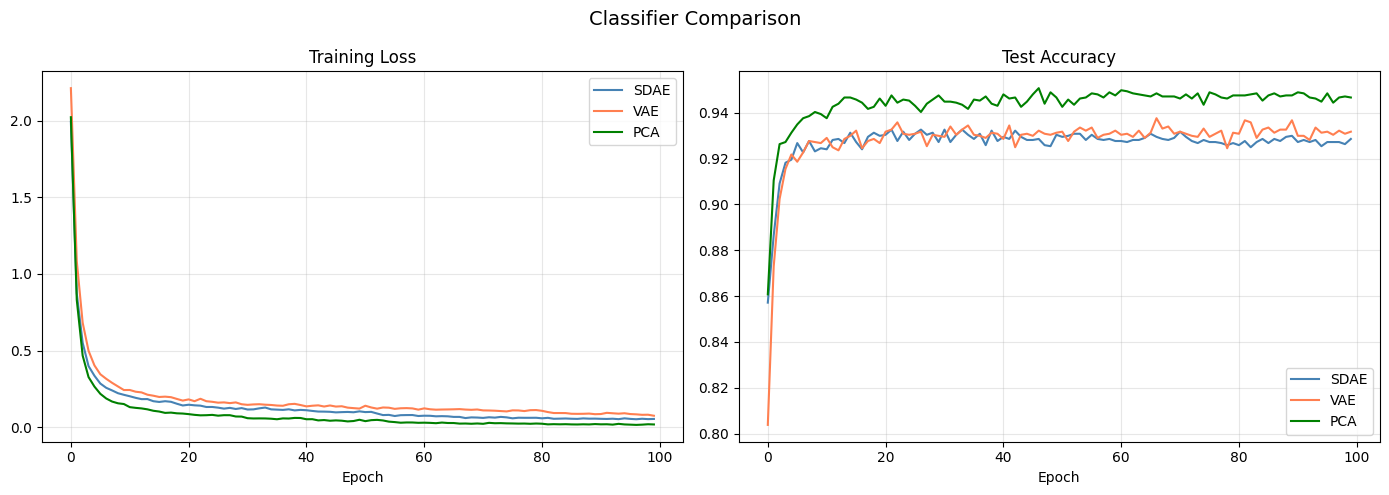

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'SDAE':'steelblue', 'VAE':'coral', 'PCA':'green'}
for name, (_, hist) in res.items():
    axes[0].plot(hist['loss'], label=name, color=colors[name])
    axes[1].plot(hist['test_acc'], label=name, color=colors[name])
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Test Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Classifier Comparison', fontsize=14); plt.tight_layout(); plt.show()

## 9. Evaluation & Comparison

In [ ]:
# Evaluate all models
preds, metrics = {}, {}
for name, Zte in [('SDAE', Z_te_s), ('VAE', Z_te_v), ('PCA', Z_te_p)]:
    clf = res[name][0]
    clf.eval()
    with torch.no_grad():
        pred = clf(torch.FloatTensor(Zte).to(device)).argmax(1).cpu().numpy()
    preds[name] = pred
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average='macro')
    f1w = f1_score(y_test, pred, average='weighted')
    metrics[name] = {'Accuracy': acc, 'F1 (Macro)': f1m, 'F1 (Weighted)': f1w}
    print(f"{name:6s} | Acc: {acc:.4f} | F1-macro: {f1m:.4f} | F1-weighted: {f1w:.4f}")

summary = pd.DataFrame(metrics).T
print("\n"); display(summary.round(4))

SDAE   | Acc: 0.9286 | F1-macro: 0.8990 | F1-weighted: 0.9266
VAE    | Acc: 0.9317 | F1-macro: 0.9010 | F1-weighted: 0.9300
PCA    | Acc: 0.9467 | F1-macro: 0.9203 | F1-weighted: 0.9457




,Accuracy,F1 (Macro),F1 (Weighted)
SDAE,0.9286,0.8990,0.9266
VAE,0.9317,0.9010,0.9300
PCA,0.9467,0.9203,0.9457


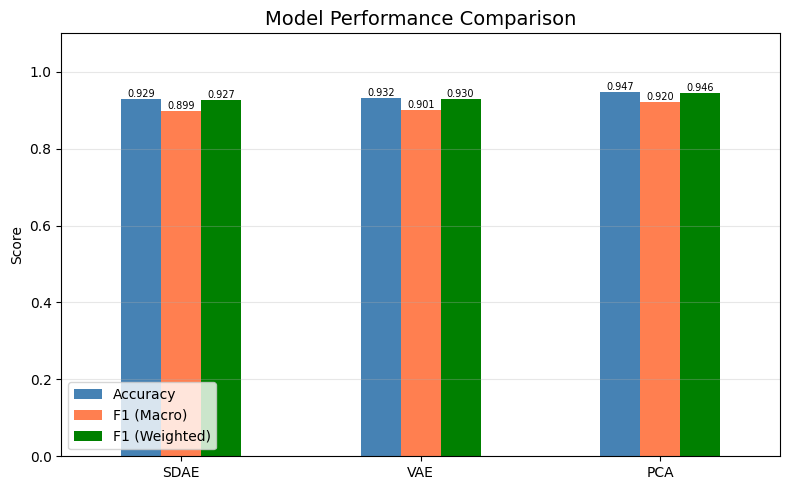

In [ ]:
# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
summary.plot(kind='bar', ax=ax, color=['steelblue','coral','green'])
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 10. Confusion Matrices

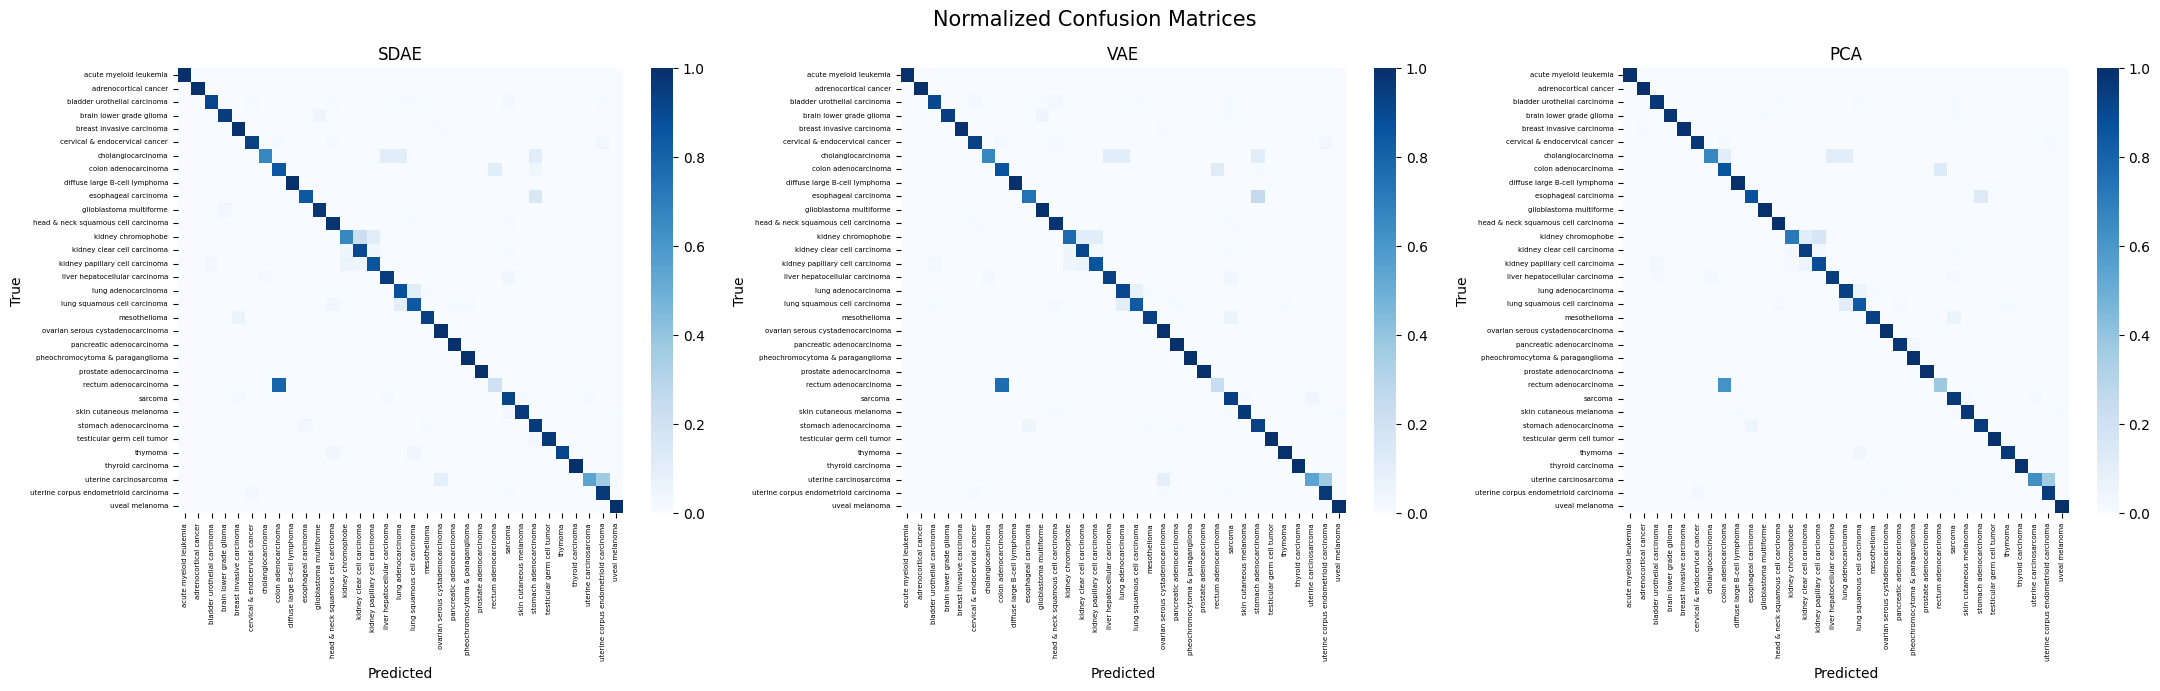

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, name in zip(axes, ['SDAE', 'VAE', 'PCA']):
    cm = confusion_matrix(y_test, preds[name])
    cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_n, annot=False, cmap='Blues', ax=ax, xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'{name}', fontsize=12); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(labelsize=5)
plt.suptitle('Normalized Confusion Matrices', fontsize=15); plt.tight_layout(); plt.show()

## 11. Per-Class Accuracy & Detailed Report

In [ ]:
# Best model report
best = max(metrics, key=lambda k: metrics[k]['Accuracy'])
print(f"Best model: {best}\n")
print(classification_report(y_test, preds[best], target_names=le.classes_))

Best model: PCA

                                       precision    recall  f1-score   support

               acute myeloid leukemia       1.00      1.00      1.00        35
                adrenocortical cancer       0.94      1.00      0.97        16
         bladder urothelial carcinoma       0.97      0.97      0.97        86
             brain lower grade glioma       1.00      0.98      0.99       106
            breast invasive carcinoma       1.00      1.00      1.00       244
       cervical & endocervical cancer       0.95      0.97      0.96        62
                   cholangiocarcinoma       0.75      0.67      0.71         9
                 colon adenocarcinoma       0.79      0.87      0.83        99
        diffuse large B-cell lymphoma       0.91      1.00      0.95        10
                 esophageal carcinoma       0.89      0.87      0.88        39
              glioblastoma multiforme       0.97      1.00      0.99        34
  head & neck squamous cell carcin

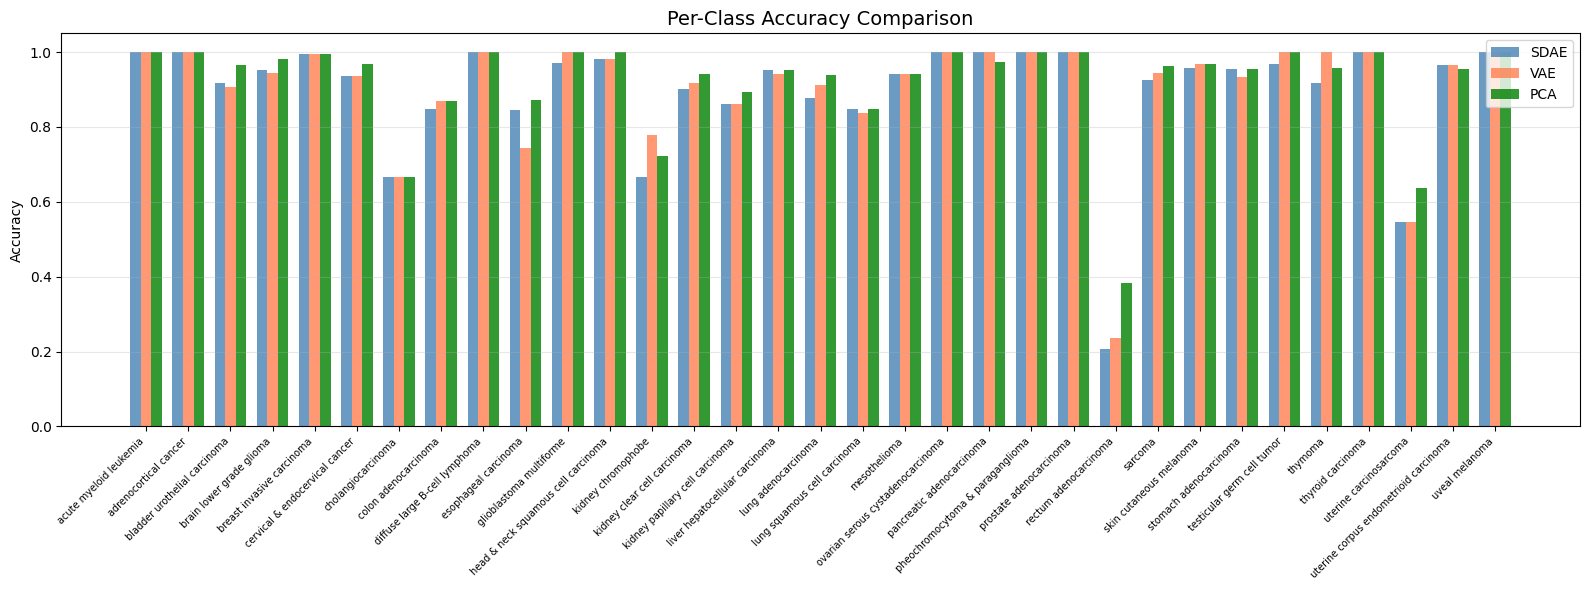

In [ ]:
# Per-class accuracy
def pca_fn(yt, yp, nc):
    return [((yp[yt==i]==i).mean() if (yt==i).sum()>0 else 0) for i in range(nc)]

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(n_classes); w = 0.25
for i, (name, color) in enumerate(colors.items()):
    ax.bar(x + (i-1)*w, pca_fn(y_test, preds[name], n_classes), w, label=name, color=color, alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(le.classes_, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Accuracy'); ax.set_title('Per-Class Accuracy Comparison', fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

## 12. Ablation Study: Effect of Latent Dimension

In [ ]:
latent_dims = [32, 64, 128, 256, 512]
abl = []
for ld in latent_dims:
    print(f"--- Latent dim = {ld} ---")
    ae = SDAE(INPUT_DIM, ld).to(device)
    o = optim.Adam(ae.parameters(), lr=1e-3)
    c = nn.MSELoss()
    ae.train()
    for _ in range(50):
        for (x,) in ae_loader:
            o.zero_grad(); xr, _ = ae(x); c(xr, x).backward(); o.step()

    ae.eval()
    with torch.no_grad():
        ztr = ae.encode(X_train_t).cpu().numpy()
        zte = ae.encode(X_test_t).cpu().numpy()

    cl = Clf(ld, n_classes).to(device)
    o2 = optim.Adam(cl.parameters(), lr=1e-3)
    c2 = nn.CrossEntropyLoss()
    ds = DataLoader(TensorDataset(torch.FloatTensor(ztr).to(device), y_train_t), batch_size=128, shuffle=True)
    cl.train()
    for _ in range(50):
        for xb, yb in ds:
            o2.zero_grad(); c2(cl(xb), yb).backward(); o2.step()

    cl.eval()
    with torch.no_grad():
        p = cl(torch.FloatTensor(zte).to(device)).argmax(1).cpu().numpy()
    a = accuracy_score(y_test, p)
    f = f1_score(y_test, p, average='macro')
    print(f"  Acc: {a:.4f}, F1: {f:.4f}")
    abl.append({'dim': ld, 'acc': a, 'f1': f})

abl_df = pd.DataFrame(abl)
display(abl_df.round(4))

--- Latent dim = 32 ---
  Acc: 0.9295, F1: 0.8866
--- Latent dim = 64 ---
  Acc: 0.9268, F1: 0.8837
--- Latent dim = 128 ---
  Acc: 0.9286, F1: 0.8893
--- Latent dim = 256 ---
  Acc: 0.9272, F1: 0.8768
--- Latent dim = 512 ---
  Acc: 0.9272, F1: 0.8916


,dim,acc,f1
0,32,0.9295,0.8866
1,64,0.9268,0.8837
2,128,0.9286,0.8893
3,256,0.9272,0.8768
4,512,0.9272,0.8916


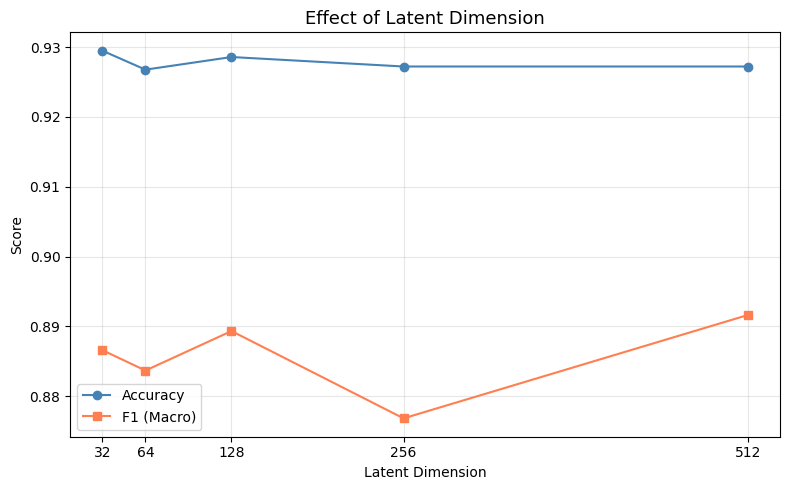

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(abl_df['dim'], abl_df['acc'], 'o-', color='steelblue', label='Accuracy')
ax.plot(abl_df['dim'], abl_df['f1'], 's-', color='coral', label='F1 (Macro)')
ax.set_xlabel('Latent Dimension'); ax.set_ylabel('Score')
ax.set_title('Effect of Latent Dimension', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xticks(latent_dims)
plt.tight_layout(); plt.show()

## 13. Summary & Discussion

### Key Findings:
1. **SDAE vs VAE vs PCA:** Compare accuracy and discuss nonlinear vs linear dimensionality reduction.
2. **Latent Space:** UMAP visualizations show cancer type clustering quality.
3. **Per-class:** Some cancers are easily classified; others (e.g., COAD vs READ) are confused due to molecular similarity.
4. **Latent Dimension:** Ablation study shows compression vs. information retention trade-off.

### Literature Comparison:
- Chen et al. (2018): 98% cancer detection accuracy with deep autoencoder on TCGA
- Way & Greene (2018): VAE with 100-dim latent space on 5,000 genes (Tybalt)
- Mohammed et al. (2021): Stacking ensemble 1D-CNN on TCGA RNA-Seq

### Future Work:
- Attention-based or Graph Neural Network architectures
- Gene importance analysis for biological interpretability
- External validation datasets
- Multi-omics integration (methylation, CNV)
